<a href="https://colab.research.google.com/github/kosebaris1/MACHINE_LEARNING/blob/LSTM/LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
!pip -q install yfinance

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)



In [10]:
tickers = ["AAPL", "GOOGL", "AMZN"]
start_date = "2015-01-01"
end_date   = "2023-12-31"

data = {}

for t in tickers:
    df = yf.download(t, start=start_date, end=end_date, progress=False)
    df = df[["Close"]].dropna()
    data[t] = df
    print(t, df.shape)


AAPL (2264, 1)
GOOGL (2264, 1)
AMZN (2264, 1)


/tmp/ipython-input-2550642310.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(t, start=start_date, end=end_date, progress=False)
/tmp/ipython-input-2550642310.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(t, start=start_date, end=end_date, progress=False)
/tmp/ipython-input-2550642310.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(t, start=start_date, end=end_date, progress=False)


In [11]:
def create_sequences(data, lookback=60):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)


def prepare_data(df, lookback=60, train_ratio=0.8):
    values = df.values.astype(np.float32)

    split = int(len(values) * train_ratio)
    train = values[:split]
    test  = values[split:]

    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train)
    test_scaled  = scaler.transform(test)

    X_train, y_train = create_sequences(train_scaled, lookback)

    combined = np.vstack((train_scaled[-lookback:], test_scaled))
    X_test, y_test = create_sequences(combined, lookback)

    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test  = X_test.reshape((X_test.shape[0],  X_test.shape[1],  1))

    return X_train, y_train, X_test, y_test, scaler


In [12]:
def build_model(lookback=60, units=64, dropout=0.2, lr=0.001):
    model = Sequential([
        LSTM(units, return_sequences=True, input_shape=(lookback, 1)),
        Dropout(dropout),

        LSTM(units),
        Dropout(dropout),

        Dense(32, activation="relu"),
        Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="mean_squared_error"
    )
    return model


In [16]:
def train_and_evaluate(
    ticker,
    df,
    lookback=60,
    epochs=20,
    batch_size=32,
    units=64,
    dropout=0.2,
    lr=0.001
):
    print("\n==============================")
    print(f"📊 {ticker} MODELİ EĞİTİLİYOR")
    print("==============================")

    X_train, y_train, X_test, y_test, scaler = prepare_data(df, lookback)

    model = build_model(
        lookback=lookback,
        units=units,
        dropout=dropout,
        lr=lr
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        verbose=1   # epoch + loss GÖRÜNÜR
    )

    #  Loss Grafiği
    plt.figure()
    plt.plot(history.history["loss"])
    plt.title(f"{ticker} - Eğitim Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss (MSE)")
    plt.show()

    #  Tahmin
    preds_scaled = model.predict(X_test)

    y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))
    preds_inv  = scaler.inverse_transform(preds_scaled)

    mse = mean_squared_error(y_test_inv, preds_inv)
    print(f"{ticker} TEST MSE: {mse:.4f}")

    # 🔹 Gerçek vs Tahmin
    plt.figure(figsize=(12,5))
    plt.plot(y_test_inv, label="Gerçek")
    plt.plot(preds_inv, label="Tahmin")
    plt.title(f"{ticker} - Gerçek vs Tahmin")
    plt.xlabel("Zaman")
    plt.ylabel("Kapanış Fiyatı")
    plt.legend()
    plt.show()

    return mse



📊 AAPL MODELİ EĞİTİLİYOR
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.0511
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0022
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0021
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0016
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0014
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0011
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0015
Epoch 8/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0012
Epoch 9/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0010
Epoch 10/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0010
Epoch 11/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0011
Epoch 12/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0010
Epoch 13/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8.6898e-04
Epoch 14/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0012
Epoch 15/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9.1854e-04
Epoch 16/20
55/5

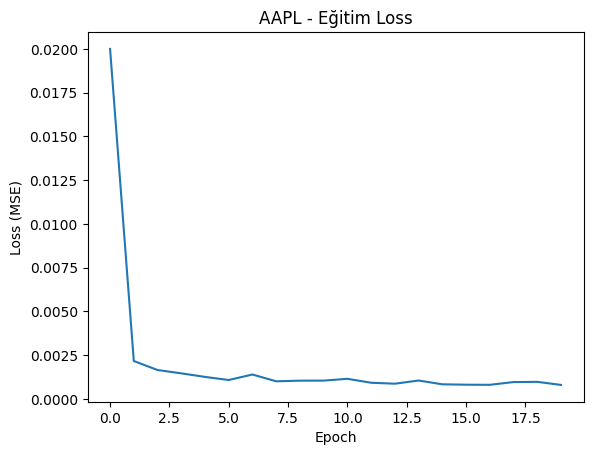

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
✅ AAPL TEST MSE: 40.4643


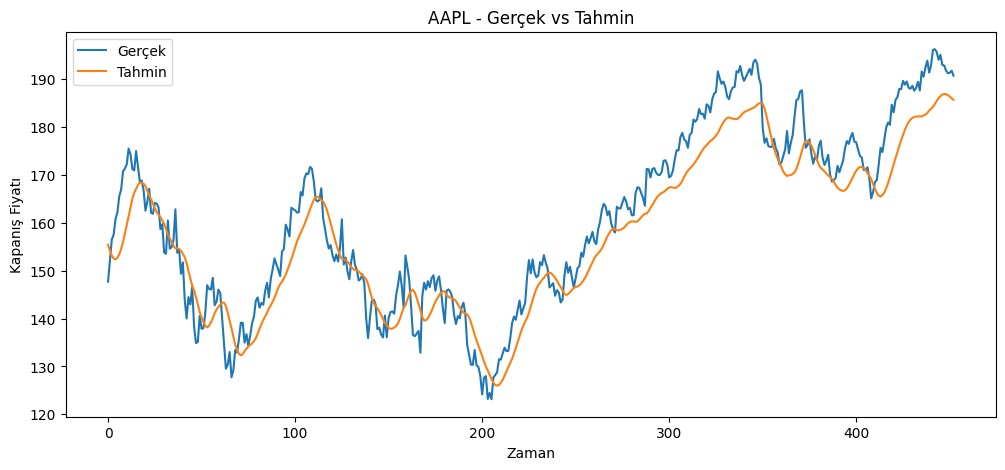


📊 GOOGL MODELİ EĞİTİLİYOR
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0403
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0019
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0016
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0016
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0016
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0011
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0014
Epoch 8/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0011
Epoch 9/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0012
Epoch 10/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0011
Epoch 11/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 9.0252e-04
Epoch 12/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0011
Epoch 13/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 9.3859e-04
Epoch 14/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 8.9592e-04
Epoch 15/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 9.7513e-04
Epoch 16/2

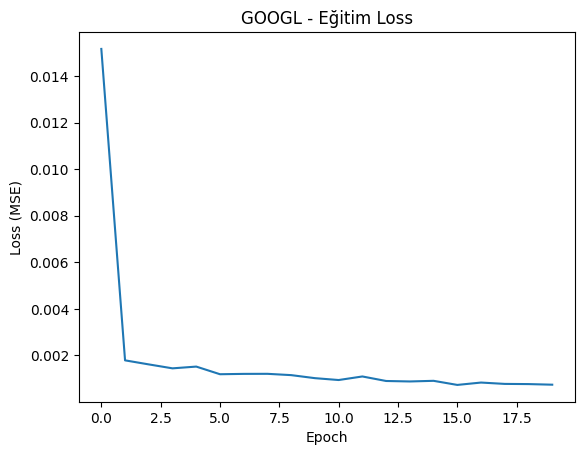

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
✅ GOOGL TEST MSE: 20.2231


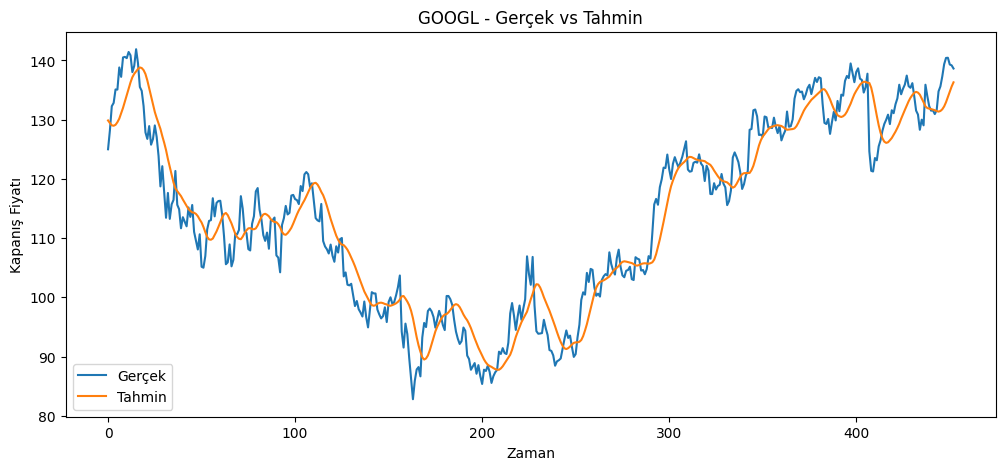


📊 AMZN MODELİ EĞİTİLİYOR
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0552
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0034
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0023
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0023
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0021
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0022
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0017
Epoch 8/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0016
Epoch 9/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0015
Epoch 10/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0014
Epoch 11/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0016
Epoch 12/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0015
Epoch 13/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0013
Epoch 14/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0013
Epoch 15/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0013
Epoch 16/20
55/55 ━━━━━━━━━━

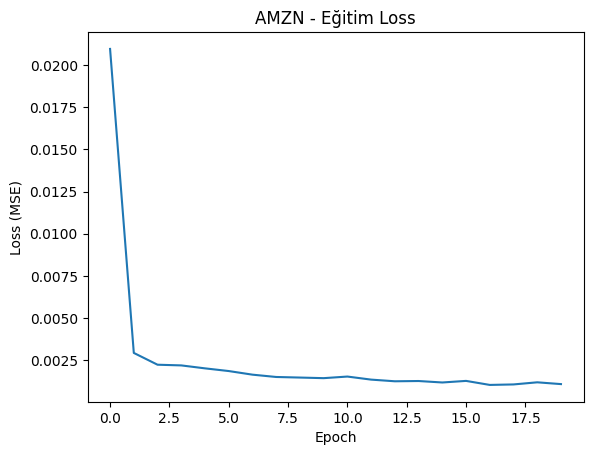

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
✅ AMZN TEST MSE: 43.2852


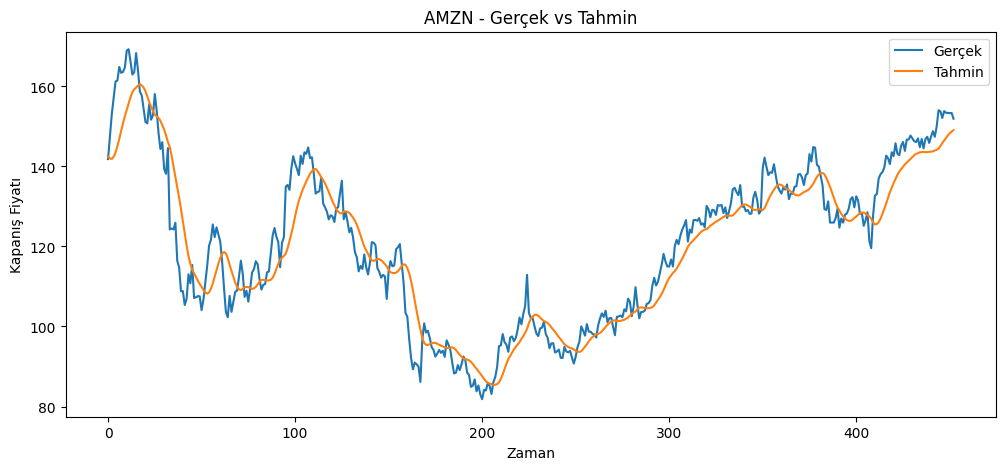

{'AAPL': 40.46426010131836,
 'GOOGL': 20.223129272460938,
 'AMZN': 43.28524398803711}

In [14]:
results = {}

for t in tickers:
    mse = train_and_evaluate(
        ticker=t,
        df=data[t],
        lookback=60,
        epochs=20,
        batch_size=32,
        units=64,
        dropout=0.2,
        lr=0.001
    )
    results[t] = mse

results


,Ticker,MSE
0,AAPL,29.546597
1,GOOGL,37.944874
2,AMZN,38.636059



📊 AAPL MODELİ EĞİTİLİYOR
Epoch 1/60


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0314
Epoch 2/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0014
Epoch 3/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0011
Epoch 4/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0010
Epoch 5/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0011
Epoch 6/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.7801e-04
Epoch 7/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 8.5453e-04
Epoch 8/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 7.6848e-04
Epoch 9/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 7.8169e-04
Epoch 10/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 9.4527e-04
Epoch 11/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 7.2026e-04
Epoch 12/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 6.8184e-04
Epoch 13/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 6.9157e-04
Epoch 14/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5.4314e-04
Epoch 15/60
108/10

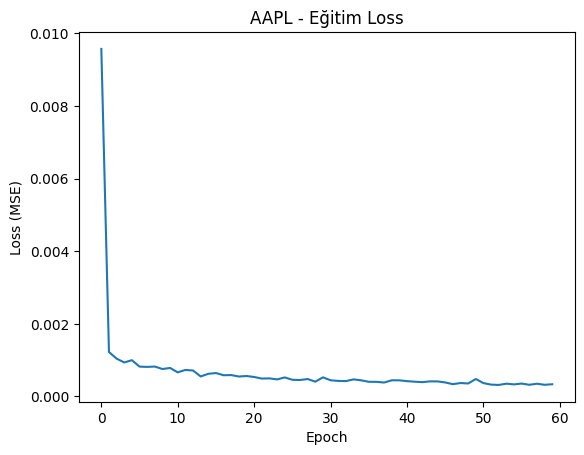

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
AAPL TEST MSE: 33.5493


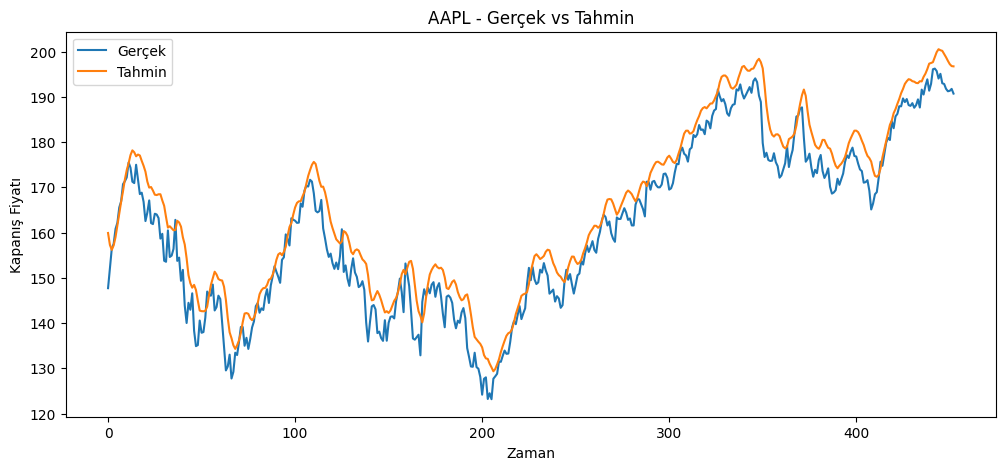


📊 GOOGL MODELİ EĞİTİLİYOR
Epoch 1/60


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0374
Epoch 2/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0012
Epoch 3/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0013
Epoch 4/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0010
Epoch 5/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 9.2036e-04
Epoch 6/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 9.3891e-04
Epoch 7/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0012
Epoch 8/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 9.1897e-04
Epoch 9/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 9.5763e-04
Epoch 10/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 8.2272e-04
Epoch 11/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.0753e-04
Epoch 12/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 7.6972e-04
Epoch 13/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 7.6717e-04
Epoch 14/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 6.9954e-04
Epoch 15/60
108/10

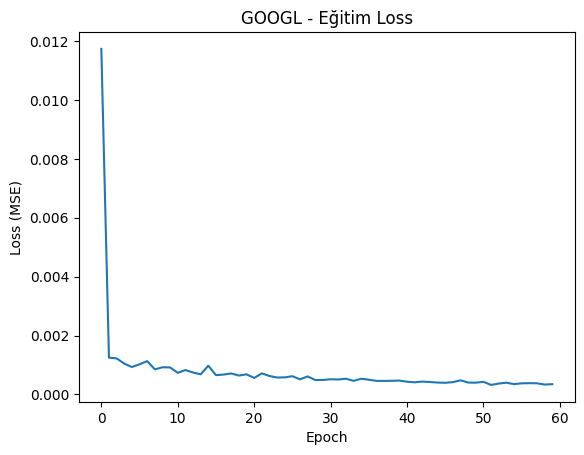

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
GOOGL TEST MSE: 18.1046


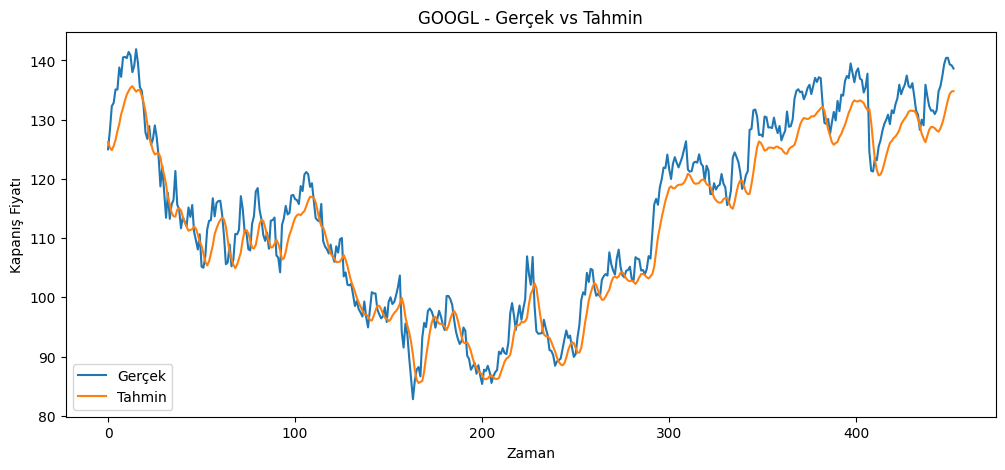


📊 AMZN MODELİ EĞİTİLİYOR
Epoch 1/60


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0496
Epoch 2/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0018
Epoch 3/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0017
Epoch 4/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0015
Epoch 5/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0016
Epoch 6/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0017
Epoch 7/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0018
Epoch 8/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0020
Epoch 9/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0012
Epoch 10/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0012
Epoch 11/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0013
Epoch 12/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0013
Epoch 13/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0011
Epoch 14/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0015
Epoch 15/60
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step 

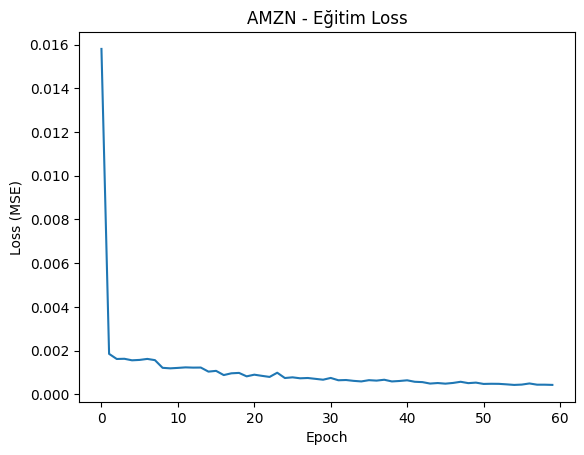

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
AMZN TEST MSE: 18.1725


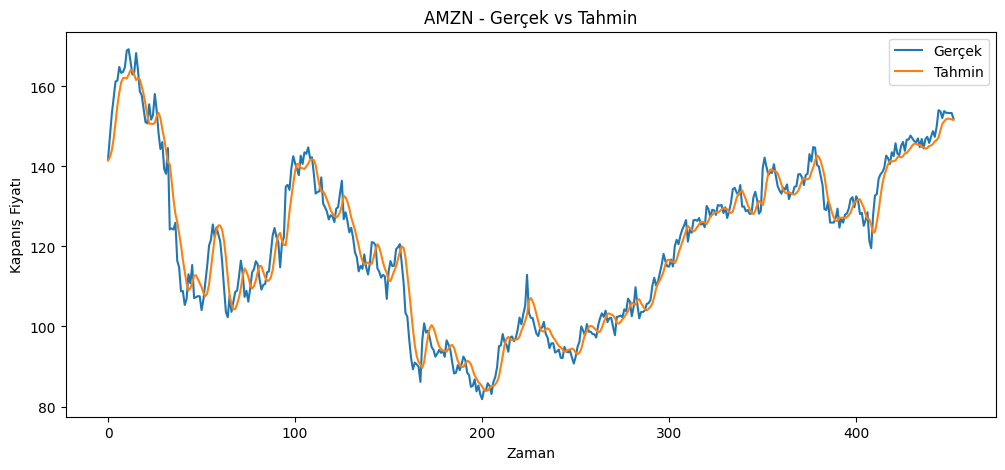

{'AAPL': 33.54931640625,
 'GOOGL': 18.10462760925293,
 'AMZN': 18.172460556030273}

In [17]:
results = {}

for t in tickers:
    mse = train_and_evaluate(
        ticker=t,
        df=data[t],
        lookback=90,
        epochs=60,
        batch_size=16,
        units=64,
        dropout=0.1,
        lr=0.0005
    )
    results[t] = mse

results
